In [21]:
df = pd.read_csv('q3_retail_promotions.csv')

import pandas as pd

df = pd.read_csv('q3_retail_promotions (1).csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


## Step 1: Data Loading

In this step, I loaded the dataset containing retail store transaction data.

The dataset includes features such as transaction date, store details, promotional information, and target variable (items_sold).

This dataset will be used to build a regression pipeline to predict the number of items sold.

In [22]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end feature
df['is_month_end'] = df['transaction_date'].dt.day >= 25
df['is_month_end'] = df['is_month_end'].astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


## Step 2: Date Feature Engineering

In this step, I extracted useful features from the transaction_date column:

- Year
- Month
- Day of week

Additionally, I created a new binary feature 'is_month_end', which indicates whether the transaction occurred near the end of the month (day >= 25).

These features help capture temporal patterns in sales.

In [23]:
df = df.sort_values(by='transaction_date')

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

## Step 3: Temporal Train-Test Split

In this step, I sorted the dataset based on transaction_date to preserve the time order.

I used the first 80% of the data as the training set and the remaining 20% as the test set.

A random split is not appropriate here because it would break the time sequence and lead to data leakage.

This approach ensures that the model is evaluated on future data.

In [24]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_cols = ['store_size', 'location_type', 'promotion_type']
numeric_cols = ['store_id', 'is_weekend', 'is_festival', 'competition_density',
                'year', 'month', 'day_of_week', 'is_month_end']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

## Step 4: Preprocessing Pipeline

In this step, I created a preprocessing pipeline using ColumnTransformer.

- Numerical features are scaled using StandardScaler
- Categorical features are encoded using OneHotEncoder

This ensures that all features are in a suitable format for model training.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['store_id', 'is_weekend',
                                                   'is_festival',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['store_size',
                                                   'location_type',
                                                   'promotion_type'])])),
                ('model', RandomForestRegressor(random_state=42))])

## Step 5: Model Training

In this step, I trained two models:

- Linear Regression
- Random Forest Regressor

Both models were implemented within pipelines to ensure consistent preprocessing and training.

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predictions
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

# Metrics
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} RMSE:", rmse)
    print(f"{name} MAE:", mae)

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")

Linear Regression RMSE: 27.121451164890626
Linear Regression MAE: 21.052926674588395
Random Forest RMSE: 30.670733403360277
Random Forest MAE: 24.179416666666665


## Step 6: Model Evaluation

In this step, I evaluated both models using:

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)

These metrics help assess prediction accuracy and error magnitude.

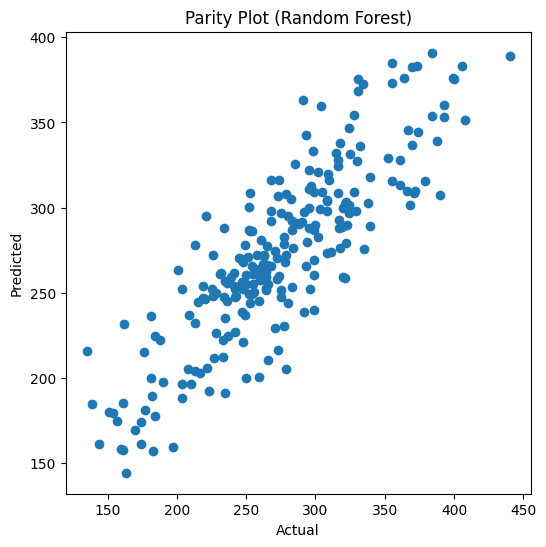

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Parity Plot (Random Forest)")
plt.show()

## Step 7: Parity Plot

This plot compares actual vs predicted values.

A good model will have points close to the diagonal line, indicating accurate predictions.

In [28]:
model = rf_pipeline.named_steps['model']
importances = model.feature_importances_

print("Feature Importances:", importances)

Feature Importances: [0.0546484  0.06167208 0.1734671  0.05090945 0.01704706 0.03737465
 0.08554495 0.0055275  0.05362657 0.02454106 0.16780129 0.05266745
 0.01666283 0.1102291  0.03025244 0.01095994 0.01598083 0.00791767
 0.02316962]


## Step 8: Feature Importance

Random Forest provides feature importance scores.

These indicate which features have the most influence on predicting items_sold.

The top features can be used for business insights and decision-making.